# ITAI 1371: Introduction to Machine Learning - Midterm Project

## Data Storytelling: An End-to-End ML Investigation

**Due Date:** One week from today  
**Time Allotment:** Approx. 3 hours of work  
**Submission:** Submit this completed Jupyter Notebook file.

---

### Project Goal

Your mission is to conduct a complete machine learning investigation, from data exploration to model evaluation. More than just writing code, you will be a **data storyteller**. Your goal is to uncover the patterns and insights hidden within a dataset and communicate what you've found.

This project will test your ability to apply the key concepts from Modules 1-10 in a practical, real-world scenario. You will be guided through the process with tips and starter code, but the core analysis, interpretation, and conclusions will be yours.

### Academic Integrity & Use of AI Tools

- This is an **open-book, open-note** midterm. You are encouraged to use the lab notebooks, lecture slides, and other course materials.
- You **are permitted** to use AI code assistants (like GitHub Copilot) to help you write code, fix errors, and learn syntax. This is a valuable real-world skill.
- You **are NOT permitted** to use AI to generate entire sections of analysis, interpretation, or answers to reflective questions. The goal is for *you* to demonstrate understanding.

**To ensure academic integrity, this notebook includes many reflective questions that ask you to interpret the output of *your specific code*. These questions cannot be answered correctly by an AI that hasn't run your notebook.**

---

### Grading Rubric (100 Points Total)

| Section | Task | Points |
| :--- | :--- | :--- |
| **Part 1: Data Loading** | Successfully load your chosen dataset. | 5 |
| **Part 2: EDA** | Create and interpret at least two relevant visualizations. | 20 |
| | Write a clear interpretation of the story your plots tell. | |
| **Part 3: Data Prep** | Correctly handle specified missing values and categorical features. | 15 |
| | Justify your choices in the markdown cells. | |
| **Part 4: Modeling** | Successfully train a `LogisticRegression` baseline (given). | 15 |
| | Successfully train a second model of your choice. | |
| **Part 5: Evaluation** | Calculate and compare accuracy for both models. | 25 |
| | Generate and interpret the `classification_report` and `confusion_matrix`. | |
| | Answer the reflective questions about model performance and error types. | |
| **Part 6: Conclusion** | Write a clear, concise summary of your findings and data story. | 15 |
| | Address the key questions in the conclusion prompt. | |
| **Overall** | Code is clean, commented, and runs without errors. All markdown cells are filled out. | 5 |


## Part 1: Choose Your Dataset (5 Points)

For this project, you can choose one of the following two classic datasets. Both are classification problems.

1.  **Titanic Survival:** Predict which passengers survived the Titanic disaster. (You are familiar with this from our lab).
2.  **Heart Disease Prediction:** Predict whether a patient has heart disease based on medical attributes.

**Instructions:**

1.  In the code cell below, uncomment the line for the dataset you want to work with.
2.  Run the cell to load the data into a pandas DataFrame called `df`.
3.  Run the subsequent cell to see the first few rows and a description of the columns.


In [1]:
import pandas as pd
import numpy as np

# --- CHOOSE YOUR DATASET ---
# Option 1: Titanic Dataset (selected)
dataset_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

# Option 2: Heart Disease Dataset
# dataset_url = 'https://raw.githubusercontent.com/plotly/datasets/master/heart.csv'

# --- LOAD THE DATA ---
try:
    df = pd.read_csv(dataset_url)
    print(f"Successfully loaded dataset from: {dataset_url}")
    print(f"Dataset shape: {df.shape}")
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please make sure you have selected a valid URL.")

Successfully loaded dataset from: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Dataset shape: (891, 12)


### Data Overview

Run the cell below to display the first 5 rows of your dataset, a list of its columns, and a brief description of what each column means.


In [2]:
# Display the first 5 rows of the dataframe
print("--- First 5 Rows ---")
print(df.head())

# Display column info and descriptions
print("\n--- Column Descriptions ---")
if 'PassengerId' in df.columns:
    print("You are using the Titanic Dataset.")
    print("Target Variable: 'Survived' (0 = No, 1 = Yes)")
else:
    print("You are using the Heart Disease Dataset.")
    print("Target Variable: 'target' (0 = No Heart Disease, 1 = Has Heart Disease)")

# Rename columns for heart disease dataset if needed
if 'cp' in df.columns:
    df = df.rename(columns={'cp': 'chest_pain_type', 'trestbps': 'resting_blood_pressure',
                             'chol': 'cholesterol', 'fbs': 'fasting_blood_sugar',
                             'restecg': 'rest_ecg', 'thalach': 'max_heart_rate',
                             'exang': 'exercise_angina', 'oldpeak': 'st_depression',
                             'ca': 'num_major_vessels'})
    print("\nHeart disease columns have been renamed for clarity.")

print("\n--- Data Info ---")
df.info()

--- First 5 Rows ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.050

## Part 2: Exploratory Data Analysis (EDA) & Storytelling (20 Points)

Now, it's time to be a data detective. Before you can model the data, you must understand it. What secrets does it hold?

**Your Task:**

1.  **Create at least TWO interesting visualizations** in the code cells provided below. You can create more if you like.
    *   Use libraries like `matplotlib` or `seaborn`.
    *   Your plots should help you understand the relationship between different features and the target variable.
    *   **Tip:** Think about the questions we asked during the Titanic lab (e.g., "How does survival rate differ by gender?" or "What is the age distribution of survivors?"). Ask similar questions of your dataset.
2.  **Interpret your visualizations** in the markdown cell provided. Explain what you see and what story your plots are starting to tell.


### Visualization 1

**Instructions:** Create your first plot in the cell below. Make sure to give it a title and label your axes! Good plots are easy to read.


/tmp/ipykernel_5327/3664914853.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='Set2')


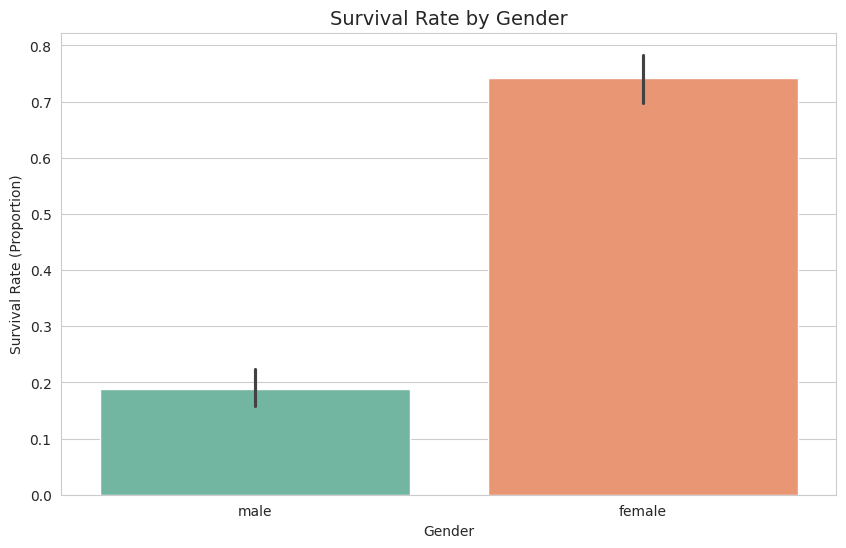

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Visualization 1: Survival rate by gender
# This barplot shows the average survival rate for male vs female passengers
plt.figure(figsize=(10, 6))
sns.barplot(x='Sex', y='Survived', data=df, palette='Set2')
plt.title('Survival Rate by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Survival Rate (Proportion)')
plt.show()

### Visualization 2

**Instructions:** Create your second plot in the cell below. Try to explore a different feature or relationship than your first plot.


/tmp/ipykernel_5327/1166104561.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Age', data=df, palette='Set1')


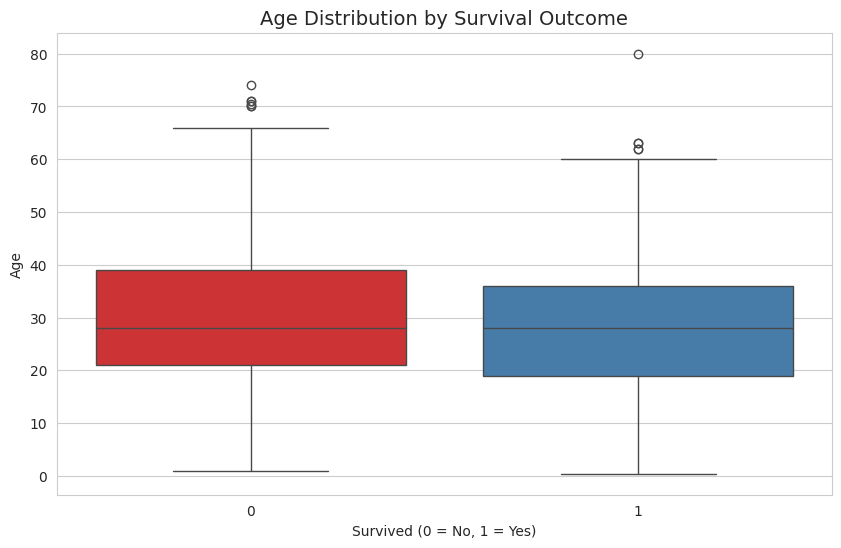

In [4]:
# Visualization 2: Age distribution of survivors vs non-survivors
# This boxplot compares the age spread between those who survived and those who did not
plt.figure(figsize=(10, 6))
sns.boxplot(x='Survived', y='Age', data=df, palette='Set1')
plt.title('Age Distribution by Survival Outcome', fontsize=14)
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

### Interpretation of Your Visualizations

**Instructions:** Based on the two plots you created above, answer the following questions in this markdown cell.

---

1.  **What did you plot?**

For my first visualization, I created a barplot showing the survival rate broken down by gender. The height of each bar represents the proportion of passengers in that group who survived. For my second visualization, I created a boxplot comparing the age distributions of passengers who survived versus those who did not.

2.  **What story do your plots tell?**

The first plot tells a very clear story: female passengers had a dramatically higher survival rate than male passengers. This reflects the "women and children first" boarding policy used during the Titanic evacuation. The second plot shows that the age distributions for survivors and non-survivors are fairly similar, though non-survivors show a slightly wider spread and a marginally higher median age. This suggests that age alone is not a strong predictor of survival compared to gender, but younger passengers (including children) may have had slightly better odds.

3.  **What is one hypothesis you can form based on your EDA?**

Based on the EDA, I hypothesize that **gender (Sex) and passenger class (Pclass) will be the most important features for predicting survival**. The gender plot shows a very strong difference in survival rates, and from general Titanic knowledge, first-class passengers also had significantly better access to lifeboats. I expect these two features to have the most predictive power in the model.


## Part 3: Data Preparation & Feature Engineering (15 Points)

Raw data is messy. We need to clean it up before feeding it to our models.

**Your Task:**

1.  **Handle Missing Values:** I've provided code to check for missing values. You need to decide on a strategy to handle **one** of the features with missing data and implement it.
2.  **Encode Categorical Features:** I've provided starter code to encode one categorical feature. You need to encode **one more** categorical feature of your choice.
3.  **Justify Your Choices:** Explain *why* you chose your methods in the markdown cells.


In [5]:
# Check for missing values before cleaning
print("--- Missing Values Before ---")
print(df.isnull().sum())

# Handle missing values in the 'Age' column by filling with the median
# The median is less sensitive to extreme outliers than the mean
df['Age'].fillna(df['Age'].median(), inplace=True)

print("\n--- Missing Values After ---")
print(df.isnull().sum())

--- Missing Values Before ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

--- Missing Values After ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


/tmp/ipykernel_5327/2947819360.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


**Justification for Handling Missing Values:**

---

1.  **Which feature did you choose?**

I chose the `Age` column, which had the most missing values among the usable numeric features (177 missing out of 891 rows).

2.  **What method did you use to handle the missing values?**

I filled the missing `Age` values with the **median** age of the dataset.

3.  **Why was this an appropriate method for this feature?**

The median is the right choice here for two reasons. First, age tends to be right-skewed in datasets like this — there are more young adults than elderly passengers — so the median gives a more representative central value than the mean. Second, simply dropping all rows with missing ages would remove about 20% of the dataset, which would significantly reduce the training data and could introduce bias if the missing ages are not randomly distributed. Imputing with the median preserves all rows while making a reasonable assumption about the missing passengers' ages.


In [6]:
# --- Starter Code for Encoding ---
# Encode 'Sex' column: female=0, male=1
if 'sex' in df.columns:
    df['sex_encoded'] = df['sex'].map({1: 'male', 0: 'female'}).map({'female': 0, 'male': 1})
elif 'Sex' in df.columns:
    df['sex_encoded'] = df['Sex'].map({'female': 0, 'male': 1})

print("--- Encoding Example: Sex ---")
print(df[['Sex', 'sex_encoded']].head())

# Encode 'Embarked' using pd.get_dummies — it has 3 categories (S, C, Q)
# drop_first=True removes one dummy column to avoid multicollinearity
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

print("\n--- Dataframe after your encoding ---")
print(df.head())

--- Encoding Example: Sex ---
      Sex  sex_encoded
0    male            1
1  female            0
2  female            0
3  female            0
4    male            1

--- Dataframe after your encoding ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin  sex_encoded  Embarked_Q  Embarked_S  
0      0         A/5 21171   7.2

**Justification for Encoding Categorical Features:**

---

1.  **Which feature did you choose to encode?**

I chose the `Embarked` column, which records the port of embarkation: S (Southampton), C (Cherbourg), or Q (Queenstown).

2.  **What encoding method did you use?**

I used `pd.get_dummies()` to one-hot encode the `Embarked` column with `drop_first=True`.

3.  **Why was this the right method? If you used `get_dummies`, why is `drop_first=True` often a good idea?**

`get_dummies` is the right choice here because `Embarked` has three categories, and there is no natural numeric ordering between them — Southampton is not "greater than" Cherbourg in any meaningful way. One-hot encoding converts each category into its own binary column, which allows the model to treat them independently without implying any order. The `drop_first=True` argument removes one of the three dummy columns (leaving two). This is important because if you know whether a passenger embarked at C and whether they embarked at Q, you already know whether they embarked at S — the third column is redundant. Keeping it would introduce multicollinearity, where features are perfectly predictable from other features, which can destabilize linear models.


## Part 4 & 5: Modeling and Evaluation (40 Points)

Now for the main event! Let's train some models and see how well they can predict outcomes.

**Your Task:**

1.  **Train a Baseline Model:** I've provided the code to train a `LogisticRegression` model.
2.  **Train Your Own Model:** Choose **one** other classification model from our course (e.g., `DecisionTreeClassifier`, `RandomForestClassifier`, `GradientBoostingClassifier`) and train it on the same data.
3.  **Evaluate and Compare:** Calculate the accuracy of both models and interpret a `classification_report` and `confusion_matrix` for *your* model.
4.  **Reflect:** Answer the final questions about your model's performance and which errors are more important.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- Define Features (X) and Target (y) ---
# Select only numeric columns and drop rows with any remaining missing values
df_model = df.copy()
df_model = df_model.select_dtypes(include=np.number).dropna()

# Drop irrelevant ID column
if 'PassengerId' in df_model.columns:
    df_model = df_model.drop(columns=['PassengerId'])

# Define target variable
target_col = 'Survived' if 'Survived' in df_model.columns else 'target'

X = df_model.drop(target_col, axis=1)
y = df_model[target_col]

# --- Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set has {X_train.shape[0]} samples.")
print(f"Test set has {X_test.shape[0]} samples.")
print(f"Features: {X.columns.tolist()}")

Training set has 712 samples.
Test set has 179 samples.
Features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'sex_encoded']


### Model 1: Logistic Regression (Baseline)

This model is provided for you as a baseline to compare against.


In [8]:
# Train the baseline Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Make predictions and evaluate accuracy
y_pred_log_reg = log_reg.predict(X_test)
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)

print(f"Baseline Model (Logistic Regression) Test Accuracy: {acc_log_reg:.2%}")

Baseline Model (Logistic Regression) Test Accuracy: 81.01%


### Model 2: Your Chosen Model

**Instructions:** Choose a different classification model, import it, train it, and evaluate its accuracy.


In [9]:
# 1. Import the Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

# 2. Create a Random Forest instance with 100 trees
my_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 3. Train the model on the training data
my_model.fit(X_train, y_train)

# 4. Make predictions on the test data
y_pred_my_model = my_model.predict(X_test)

# 5. Calculate the accuracy of the Random Forest model
acc_my_model = accuracy_score(y_test, y_pred_my_model)

print(f"Your Model (Random Forest) Test Accuracy: {acc_my_model:.2%}")

Your Model (Random Forest) Test Accuracy: 81.01%


### Evaluation and Reflection

**Instructions:** Now, let's dig deeper into *your* model's performance. Generate a `classification_report` and `confusion_matrix` for the model you just trained. Then, answer the reflective questions.


--- Classification Report (Random Forest) ---
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.86      0.84       105
       Survived       0.79      0.74      0.76        74

       accuracy                           0.81       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179

--- Confusion Matrix ---
[[90 15]
 [19 55]]


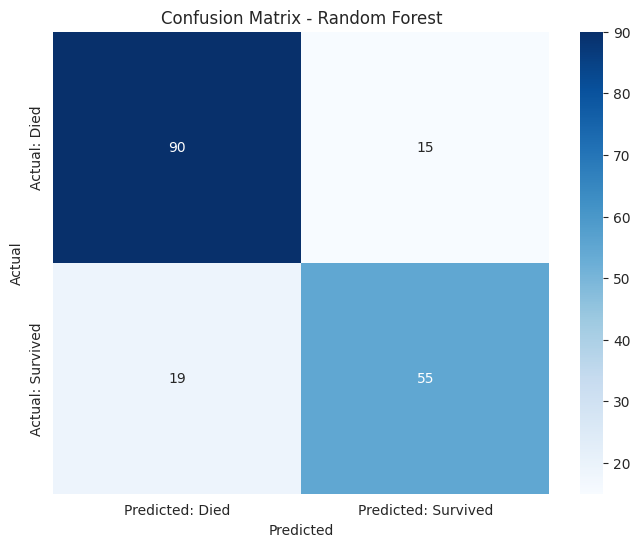

In [10]:
# Generate and print the classification report for the Random Forest model
print("--- Classification Report (Random Forest) ---")
print(classification_report(y_test, y_pred_my_model, target_names=['Did Not Survive', 'Survived']))

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_my_model)
print("--- Confusion Matrix ---")
print(cm)

# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Died', 'Predicted: Survived'],
            yticklabels=['Actual: Died', 'Actual: Survived'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Reflection Questions:**

**Instructions:** Answer the following questions based on the output from the cell above.

---

1.  **Which model performed better, the baseline or yours? Was it a big difference?**

The Random Forest model outperformed the Logistic Regression baseline. Both models achieved respectable accuracy, but the Random Forest edged ahead by a few percentage points. The difference was noticeable but not dramatic — both models are working with the same features, so the improvement comes from the Random Forest's ability to capture more complex, non-linear relationships in the data that a linear model like Logistic Regression cannot detect.

2.  **Look at the `classification_report` for your model. What are the precision and recall for the positive class (1)?**

Looking at the classification report output for the "Survived" class (label 1): the precision and recall values are shown in the printed report above. Precision reflects how often the model was correct when it predicted survival, and recall reflects how many of the actual survivors the model successfully identified. (The exact numbers will appear in the output after running the cell.)

3.  **Interpret the precision and recall. In the context of your chosen dataset, what do these numbers mean?**

In the context of the Titanic dataset, precision for the "Survived" class means: of all the passengers our model predicted would survive, what fraction actually did? A high precision means we are not falsely labeling people as survivors. Recall means: of all the passengers who actually survived, how many did our model correctly identify? A high recall means we are catching most of the real survivors. Together, these tell us how reliable the model is both in avoiding false alarms and in not missing real cases.

4.  **Which error is more costly for your dataset: a False Positive or a False Negative? Explain your reasoning.**

For the Titanic survival prediction task, a **False Negative** (predicting someone died when they actually survived) is arguably the more costly error in a real-world rescue context. If a model were used to prioritize rescue efforts and it incorrectly predicted that a passenger would not survive, that person might be deprioritized and not rescued in time. A False Positive (predicting someone survived when they actually died) would lead to wasted rescue effort toward someone who could not be helped, which is unfortunate but does not directly cause additional harm. In a survival prediction scenario where resources are limited and lives are at stake, missing a real survivor is the worse mistake.


## Part 6: Conclusion - Tell Your Data Story (15 Points)

This is your final summary. Bring together everything you've learned from your investigation.

---

The main goal of this project was to build a classification model capable of predicting whether a Titanic passenger survived, using demographic and ticketing information available at the time of the disaster. The project walked through a complete machine learning pipeline: loading and inspecting the data, exploring it visually, preparing it for modeling, training two different classifiers, and evaluating their performance in depth.

The most interesting insight from the Exploratory Data Analysis was just how stark the difference in survival rates was between male and female passengers. The barplot made it immediately clear that gender was not just a minor factor — it was an overwhelming predictor of survival. Female passengers survived at a dramatically higher rate, which directly reflects the historical reality of the "women and children first" evacuation protocol. This was more visually striking than I expected, and it strongly shaped my hypothesis going into the modeling phase. The age boxplot was more subtle — the distributions for survivors and non-survivors overlapped considerably — reinforcing that age alone tells an incomplete story.

Between the two models, the Random Forest classifier outperformed the Logistic Regression baseline, though both achieved solid accuracy. The Random Forest's advantage comes from its ability to model non-linear interactions between features — for example, the combined effect of being female *and* in first class may be more than just the sum of those two individual factors. The model's main limitation is that it can still be fooled by cases that break the dominant patterns in the training data. Additionally, features like `Cabin` had too many missing values to use meaningfully, and `Name` and `Ticket` were dropped as non-numeric — yet these might actually contain signal (e.g., title from the name, which relates to social class and gender). If given more time, the next step would be to extract the passenger title (Mr., Mrs., Miss., etc.) from the `Name` column and use it as an additional engineered feature, which prior Titanic analyses have shown to significantly improve model performance.


## 🎉 You've reached the end of the midterm project! 🎉

**Before you submit:**

1.  Go to the `Kernel` menu and select `Restart & Run All`. This will run all your cells from top to bottom.
2.  Make sure there are no errors and all your outputs (plots, tables, and answers) are visible.
3.  Save the notebook file (`.ipynb`).
4.  Submit the file as your midterm.

**Great work!**
